In [4]:
import sys
from pathlib import Path

repo = Path.cwd()
sys.path.insert(0, str(repo / "src"))

import bpy
print(bpy.app.version_string)

5.0.1


In [5]:
from IPython.display import Image, display, Video

from scene.render_offline import (
    render_still,
    render_camera_motion_sequence,
    frames_to_video,
)

In [6]:
object_path = repo / "data" / "airplane_010.blend"

output_root = repo / "data" / "renders" / "airplane_demo"
still_path = output_root / "still_test.png"
sequence_dir = output_root / "motion_sequence"
video_path = sequence_dir / "rgb_motion.mp4"

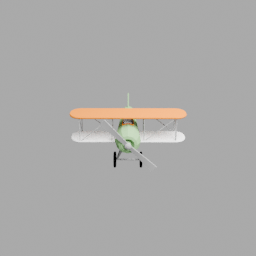

In [8]:
result = render_still(
    object_path=object_path,
    output_path=still_path,
    resolution=256,
    samples=32,
    use_gpu=True,
    object_target_size=1.2,
    camera_position=(0.0, -4.0, 1.8),
    camera_target=(0.0, 0.0, 0.0),
    focal_length=50.0,
    light_location=(2.5, -2.5, 4.0),
    light_strength=2000.0,
)

display(Image(filename=str(still_path)))

In [9]:
seq = render_camera_motion_sequence(
    object_path=object_path,
    output_dir=sequence_dir,
    num_frames=120,
    fps=60,
    resolution=128,
    samples=16,
    use_gpu=True,
    object_target_size=1.2,
    camera_position=(0.0, -4.0, 1.8),
    camera_target=(0.0, 0.0, 0.0),
    focal_length=50.0,

    drift_sigma_deg=(0.003, 0.003),
    microsaccade_rate_hz=5.0,
    microsaccade_amp_deg=(0.05, 0.25),
    microsaccade_dur_ms=(10, 25),
    jitter_sigma_deg=(0.005, 0.005),

    seed=0,
)

In [ ]:
video_file = frames_to_video(
    frames_dir=seq["frames_dir"],
    output_video=video_path,
    fps=60,
)

Video(str(video_path), embed=True)

: 